In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\chenn\Documents\NareshIT\projects\House-Price-Prediction-main\.ipynb_checkpoints\Hyderbad_House_price.csv")

In [2]:
df.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [3]:
df.columns

Index(['Unnamed: 0', 'title', 'location', 'price(L)', 'rate_persqft',
       'area_insqft', 'building_status'],
      dtype='str')

In [4]:
df.shape

(3660, 7)

In [5]:
num=df.select_dtypes(exclude='str').columns

In [6]:
cat=df.select_dtypes(include='str').columns

In [7]:
df.isnull().sum().sort_index()

Unnamed: 0         0
area_insqft        0
building_status    0
location           0
price(L)           0
rate_persqft       0
title              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['price(L)'].describe()

count    3660.000000
mean      109.624350
std       197.596948
min         1.320000
25%        26.137500
50%        61.130000
75%       116.000000
max      3600.000000
Name: price(L), dtype: float64

Text(0.5, 1.0, 'Distribution of House Prices')

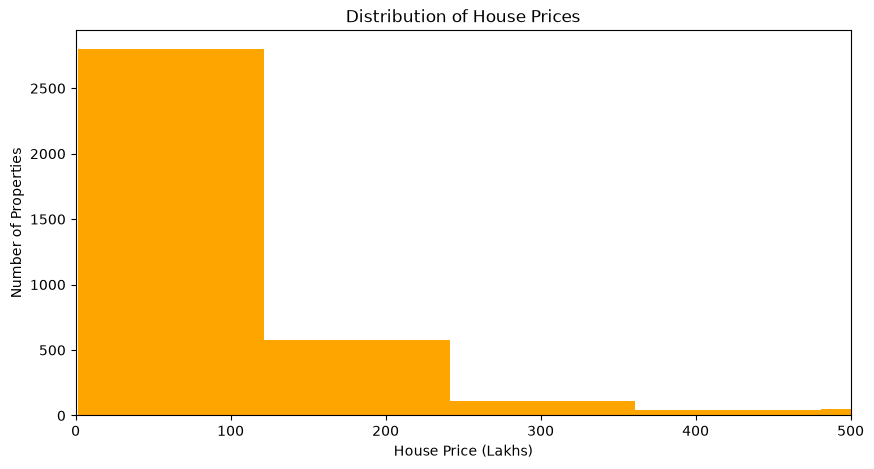

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df['price(L)'],bins=30,color='orange')
plt.xlim(0,500)
plt.xlabel('House Price (Lakhs)')
plt.ylabel('Number of Properties')
plt.title('Distribution of House Prices')

In [11]:
df['area_insqft'].describe()

count     3660.000000
mean      2023.506284
std       1829.832163
min        118.000000
25%       1280.000000
50%       1620.000000
75%       2080.000000
max      45000.000000
Name: area_insqft, dtype: float64

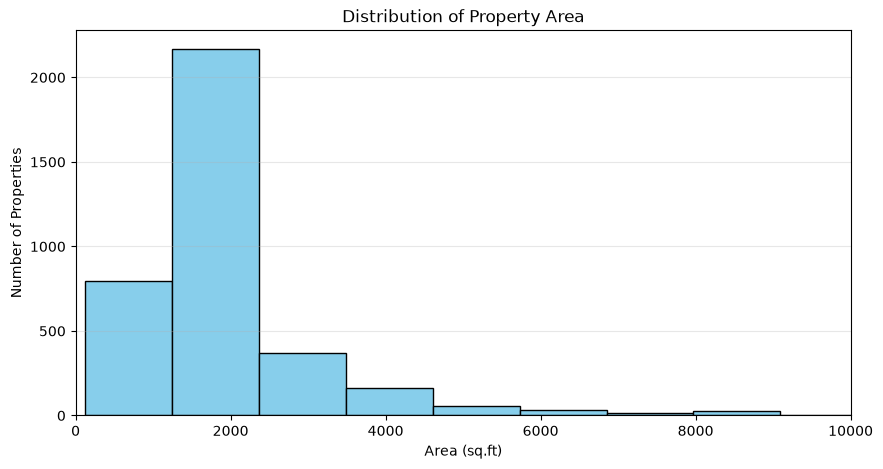

In [12]:
plt.figure(figsize=(10,5))
plt.xlim(0,10000)
plt.hist(df['area_insqft'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('Area (sq.ft)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Property Area')

plt.grid(axis='y', alpha=0.3)

Text(0.5, 1.0, 'Area VS price')

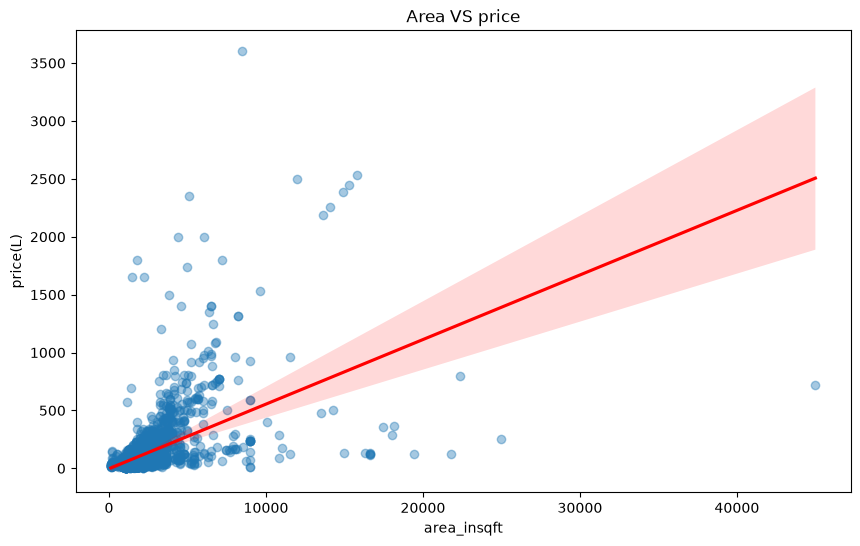

In [13]:
import seaborn as sns
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='area_insqft',
    y='price(L)',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
plt.xlabel('area_insqft')
plt.ylabel('price(L)')
plt.title('Area VS price')

In [14]:
from scipy.stats import pearsonr
l1 = df['area_insqft']
l2 = df['price(L)']
corr, _ = pearsonr(l1, l2)
print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: 0.516


In [15]:
df['rate_persqft'].describe()

count      3660.000000
mean       5165.003005
std        5316.490320
min         125.000000
25%        1555.000000
50%        4703.000000
75%        6800.000000
max      112474.000000
Name: rate_persqft, dtype: float64

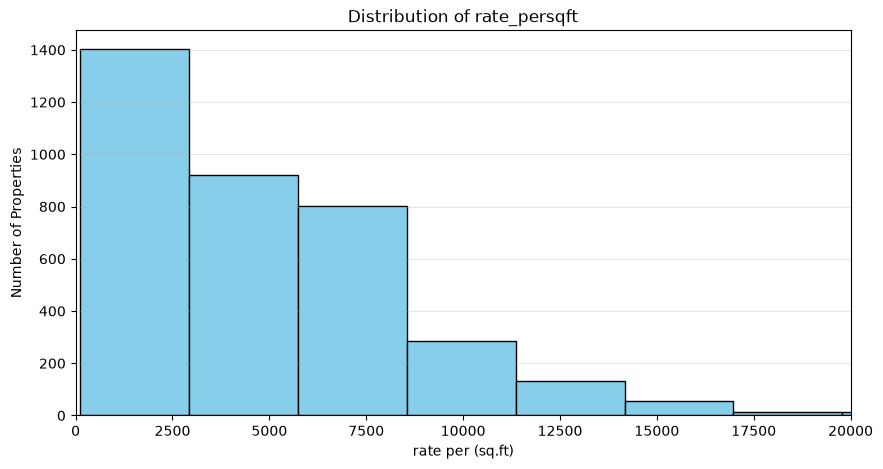

In [16]:
plt.figure(figsize=(10,5))
plt.xlim(0,20000)
plt.hist(df['rate_persqft'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('rate per (sq.ft)')
plt.ylabel('Number of Properties')
plt.title('Distribution of rate_persqft')

plt.grid(axis='y', alpha=0.3)

Text(0.5, 1.0, 'rate_insqft VS price')

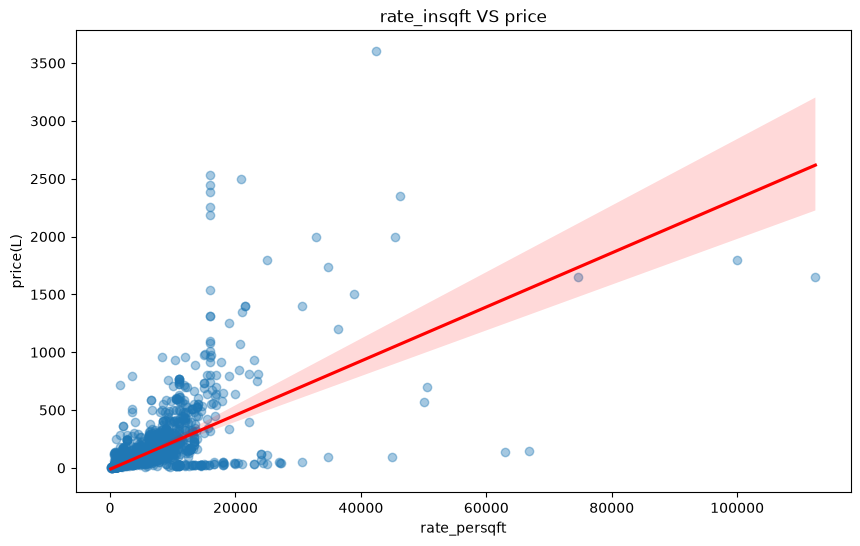

In [17]:

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='rate_persqft',
    y='price(L)',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
plt.xlabel('rate_persqft')
plt.ylabel('price(L)')
plt.title('rate_insqft VS price')

In [18]:
from scipy.stats import pearsonr
l1=df['rate_persqft']
l2=df['price(L)']
corr,p_value=pearsonr(l1,l2)
print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: 0.629


In [19]:
location_count=df['location'].value_counts().head(15).tolist()
location=df['location'].value_counts().head(15).index.tolist()

In [20]:
df['location'].nunique()

359

(array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180.]),
 [Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140'),
  Text(160.0, 0, '160'),
  Text(180.0, 0, '180')])

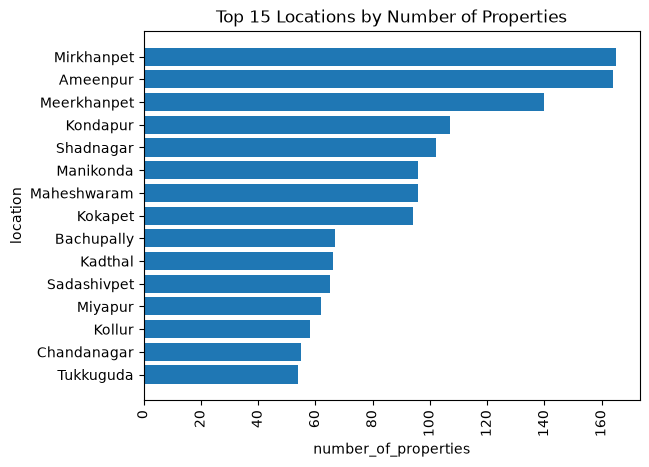

In [21]:
plt.Figure(figsize=(10,6))
plt.barh(location[::-1],location_count[::-1])
plt.title('Top 15 Locations by Number of Properties')
plt.xlabel('number_of_properties')
plt.ylabel('location')
plt.xticks(rotation=90)

In [22]:
dic={

}
for i in location:
    dic[i]= df[df['location'] == i]['price(L)'].mean()

In [23]:
dic

{'Mirkhanpet': np.float64(24.22084848484848),
 'Ameenpur': np.float64(99.40493902439023),
 'Meerkhanpet': np.float64(20.793000000000003),
 'Kondapur': np.float64(169.33897196261682),
 'Shadnagar': np.float64(30.32313725490196),
 'Manikonda': np.float64(125.88250000000001),
 'Maheshwaram': np.float64(37.28791666666667),
 'Kokapet': np.float64(392.25382978723405),
 'Bachupally': np.float64(105.43626865671642),
 'Kadthal': np.float64(48.869393939393944),
 'Sadashivpet': np.float64(67.52953846153846),
 'Miyapur': np.float64(85.5446774193548),
 'Kollur': np.float64(158.62448275862067),
 'Chandanagar': np.float64(87.45854545454544),
 'Tukkuguda': np.float64(67.62407407407406)}

In [24]:
df_location = pd.DataFrame(list(dic.items()), columns=['location', 'avg_price'])

In [25]:
df_location

,location,avg_price
0,Mirkhanpet,24.220848
1,Ameenpur,99.404939
2,Meerkhanpet,20.793000
3,Kondapur,169.338972
4,Shadnagar,30.323137
5,Manikonda,125.882500
6,Maheshwaram,37.287917
7,Kokapet,392.253830
8,Bachupally,105.436269
9,Kadthal,48.869394


Text(0.5, 0, 'location')

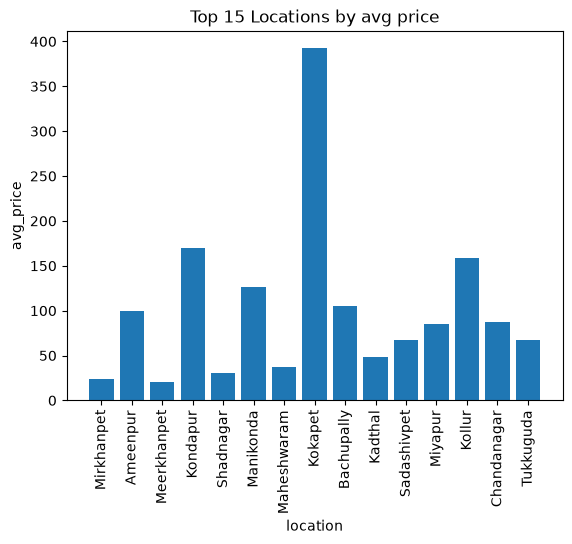

In [26]:
plt.bar(df_location['location'],df_location['avg_price'])
plt.xticks(rotation=90)
plt.title('Top 15 Locations by avg price')
plt.ylabel('avg_price')
plt.xlabel('location')

In [27]:
df['building_status'].nunique()

4

In [28]:
df['building_status'].value_counts()

building_status
New                   1378
Under Construction    1161
Ready to move          882
Resale                 239
Name: count, dtype: int64

In [29]:
build_stat_dic=df.groupby('building_status')['price(L)'].mean().to_dict()

In [30]:
df_build_status = pd.DataFrame(list(build_stat_dic.items()), columns=['building_status', 'avg_price'])

In [31]:
df_build_status

,building_status,avg_price
0,New,36.067743
1,Ready to move,168.870238
2,Resale,78.866360
3,Under Construction,158.252506


Text(0.5, 0, 'building_status')

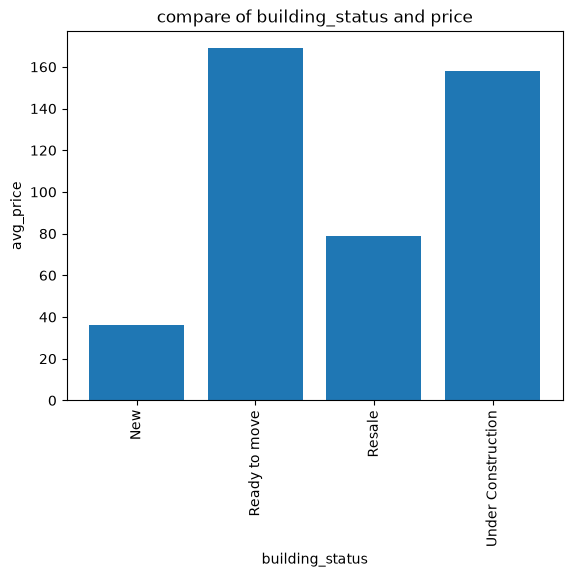

In [32]:
plt.bar(df_build_status['building_status'],df_build_status['avg_price'])
plt.xticks(rotation=90)
plt.title('compare of building_status and price')
plt.ylabel('avg_price')
plt.xlabel('building_status')

In [33]:
df['title'].nunique()

25

In [34]:
df['title'].value_counts().head(15)

title
Residential Plot           1617
3 BHK Apartment             798
2 BHK Apartment             667
4 BHK Apartment             114
2 BHK Independent House     101
4 BHK Villa                  94
3 BHK Villa                  82
4 BHK Independent House      44
3 BHK Independent House      25
5 BHK Villa                  22
2 BHK Independent Floor      21
5 BHK Independent House      18
1 BHK Apartment              15
3 BHK Independent Floor       7
5 BHK Apartment               6
Name: count, dtype: int64

In [35]:
title_dic=df.groupby('title')['price(L)'].mean().to_dict()

In [36]:

bhk = []
apartment = []
villa = []
independent_house = []
independent_floor = []

for i in range(1, 6):

    bhk.append(i)

    apartment.append(
        df[df['title'].str.contains(f'{i} BHK Apartment')]['price(L)'].mean()
    )

    villa.append(
        df[df['title'].str.contains(f'{i} BHK Villa')]['price(L)'].mean()
    )

    independent_house.append(
        df[df['title'].str.contains(f'{i} BHK Independent House')]['price(L)'].mean()
    )

    independent_floor.append(
        df[df['title'].str.contains(f'{i} BHK Independent Floor')]['price(L)'].mean()
    )

In [37]:
df_bhk = pd.DataFrame({
    'BHK': list(bhk),
    'Apartment': list(apartment),
    'Villa': list(villa),
    'Independent House': list(independent_house),
    'Independent Floor': list(independent_floor)
})

In [38]:
df_bhk

,BHK,Apartment,Villa,Independent House,Independent Floor
0,1,35.328000,NaN,57.000000,NaN
1,2,68.597091,85.333333,139.707624,66.619048
2,3,123.845251,186.646951,184.562800,162.428571
3,4,431.977719,474.787234,299.090909,485.000000
4,5,2222.833333,602.863636,221.388889,NaN


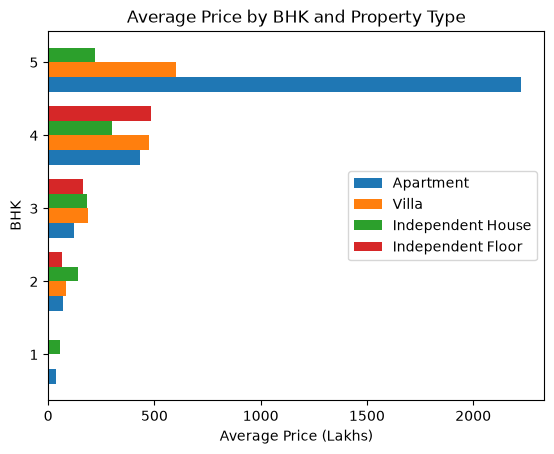

In [39]:
import numpy as np

y = np.arange(len(df_bhk))
height = 0.2

plt.barh(y - 0.3, df_bhk['Apartment'], height, label='Apartment')
plt.barh(y - 0.1, df_bhk['Villa'], height, label='Villa')
plt.barh(y + 0.1, df_bhk['Independent House'], height, label='Independent House')
plt.barh(y + 0.3, df_bhk['Independent Floor'], height, label='Independent Floor')

plt.yticks(y, df_bhk['BHK'])
plt.xlabel('Average Price (Lakhs)')
plt.ylabel('BHK')
plt.title('Average Price by BHK and Property Type')
plt.legend()
plt.show()

Text(0.5, 1.0, 'price(L)')

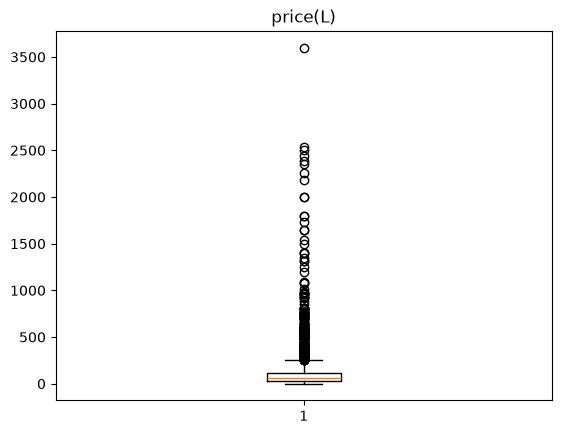

In [40]:
plt.boxplot(df['price(L)'])
plt.title('price(L)')

Text(0.5, 1.0, 'area_insqft')

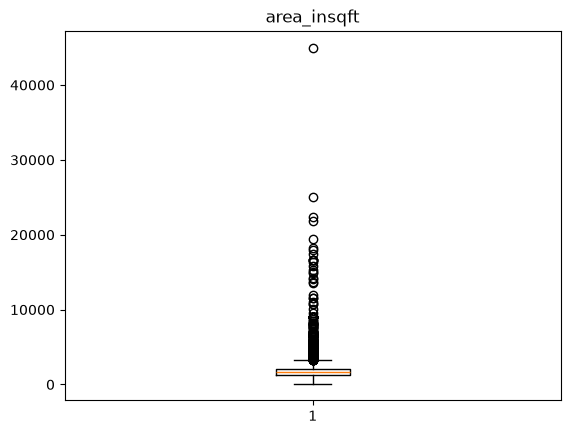

In [41]:
plt.boxplot(df['area_insqft'])
plt.title('area_insqft')

Text(0.5, 1.0, 'rate_persqft')

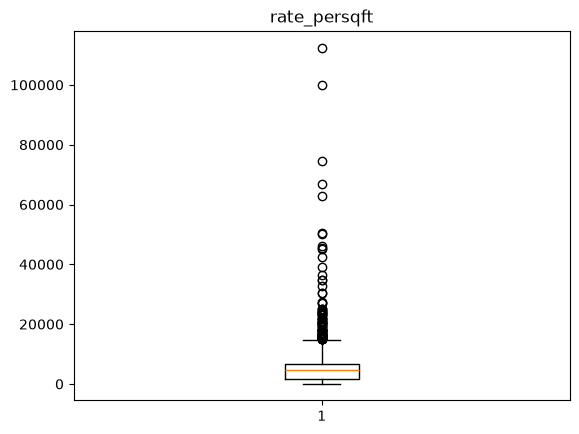

In [42]:
plt.boxplot(df['rate_persqft'])
plt.title('rate_persqft')

In [43]:
df.nlargest(10, 'price(L)')[[
    'title',
    'location',
    'price(L)',
    'area_insqft',
    'rate_persqft'
]]

,title,location,price(L),area_insqft,rate_persqft
2886,6 BHK Villa,Jubilee Hills,3600.0,8500,42352
821,5 BHK Apartment,Kokapet,2531.0,15825,16000
198,7 BHK Independent House,Banjara Hills,2500.0,12000,20833
823,5 BHK Apartment,Kokapet,2444.0,15276,16000
825,5 BHK Apartment,Kokapet,2388.0,14927,16000
3519,4 BHK Villa,Nanakramguda,2350.0,5090,46168
832,5 BHK Apartment,Khajiguda,2255.0,14099,16000
838,5 BHK Apartment,Khajiguda,2184.0,13655,16001
1411,4 BHK Villa,Kokapet,2000.0,4396,45495
2880,4 BHK Independent House,Jubilee Hills,2000.0,6084,32873


In [44]:
df.nlargest(10, 'price(L)')

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
2886,2886,6 BHK Villa,Jubilee Hills,3600.0,42352,8500,Ready to move
821,821,5 BHK Apartment,Kokapet,2531.0,16000,15825,Under Construction
198,198,7 BHK Independent House,Banjara Hills,2500.0,20833,12000,Ready to move
823,823,5 BHK Apartment,Kokapet,2444.0,16000,15276,Under Construction
825,825,5 BHK Apartment,Kokapet,2388.0,16000,14927,Under Construction
3519,3519,4 BHK Villa,Nanakramguda,2350.0,46168,5090,Ready to move
832,832,5 BHK Apartment,Khajiguda,2255.0,16000,14099,Under Construction
838,838,5 BHK Apartment,Khajiguda,2184.0,16001,13655,Under Construction
1411,1411,4 BHK Villa,Kokapet,2000.0,45495,4396,Ready to move
2880,2880,4 BHK Independent House,Jubilee Hills,2000.0,32873,6084,Ready to move


In [45]:
df.groupby(df['building_status'])['price(L)'].mean()

building_status
New                    36.067743
Ready to move         168.870238
Resale                 78.866360
Under Construction    158.252506
Name: price(L), dtype: float64

In [46]:
df.groupby(df['building_status'])['area_insqft'].mean()

building_status
New                   1966.029028
Ready to move         1920.115646
Resale                3027.543933
Under Construction    1963.583118
Name: area_insqft, dtype: float64

In [47]:
df.groupby('building_status')['rate_persqft'].mean()

building_status
New                   2433.600145
Ready to move         7418.387755
Resale                3245.175732
Under Construction    7090.262705
Name: rate_persqft, dtype: float64

<Axes: >

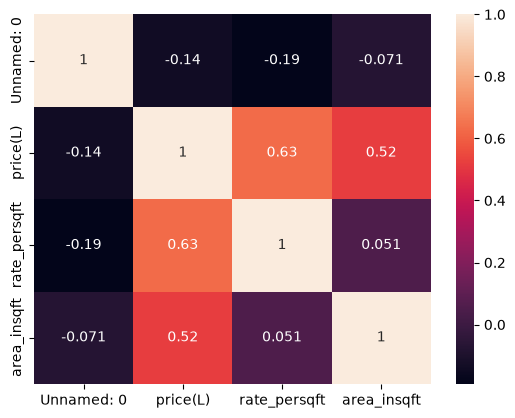

In [48]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [49]:
df.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [50]:
df['calculated_price'] = (
    df['area_insqft'] * df['rate_persqft']
) / 100000

In [51]:
df['difference'] = abs(
    df['price(L)'] - df['calculated_price']
)

In [52]:
df[['price(L)','calculated_price','difference']]

,price(L),calculated_price,difference
0,108.00,108.3000,0.3000
1,85.80,85.8000,0.0000
2,55.64,55.6400,0.0000
3,60.48,60.4879,0.0079
4,113.00,113.9810,0.9810
...,...,...,...
3655,60.00,60.0000,0.0000
3656,65.00,65.0000,0.0000
3657,65.00,65.0000,0.0000
3658,55.00,55.0000,0.0000


In [53]:
df.columns

Index(['Unnamed: 0', 'title', 'location', 'price(L)', 'rate_persqft',
       'area_insqft', 'building_status', 'calculated_price', 'difference'],
      dtype='str')

In [54]:
df['bhk'] = df['title'].str.extract(r'(\d+)')

In [55]:
df['property_type'] = df['title'].str.replace(r'\d+\s*BHK\s*', '', regex=True)

In [56]:
df[['title', 'bhk', 'property_type']].head(20)

,title,bhk,property_type
0,3 BHK Apartment,3,Apartment
1,3 BHK Apartment,3,Apartment
2,2 BHK Apartment,2,Apartment
3,2 BHK Apartment,2,Apartment
4,3 BHK Apartment,3,Apartment
5,3 BHK Apartment,3,Apartment
6,Residential Plot,NaN,Residential Plot
7,3 BHK Apartment,3,Apartment
8,3 BHK Apartment,3,Apartment
9,3 BHK Apartment,3,Apartment


In [57]:
df['location'].nunique()
df['building_status'].nunique()
df['property_type'].nunique()

6

In [58]:
df.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status,calculated_price,difference,bhk,property_type
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction,108.3000,0.3000,3,Apartment
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction,85.8000,0.0000,3,Apartment
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction,55.6400,0.0000,2,Apartment
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction,60.4879,0.0079,2,Apartment
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction,113.9810,0.9810,3,Apartment


In [59]:
df.isnull().sum()

Unnamed: 0             0
title                  0
location               0
price(L)               0
rate_persqft           0
area_insqft            0
building_status        0
calculated_price       0
difference             0
bhk                 1617
property_type          0
dtype: int64

In [60]:
df.drop(
    columns=['Unnamed: 0', 'rate_persqft', 'calculated_price', 'difference', 'title'],
    inplace=True
)

In [61]:
df.head()

,location,price(L),area_insqft,building_status,bhk,property_type
0,Nizampet,108.00,1805,Under Construction,3,Apartment
1,Bachupally,85.80,1560,Under Construction,3,Apartment
2,Dundigal,55.64,1070,Under Construction,2,Apartment
3,Pocharam,60.48,1210,Under Construction,2,Apartment
4,Kollur,113.00,1900,Under Construction,3,Apartment


In [62]:
df['property_type'].value_counts()

property_type
Residential Plot         1617
Apartment                1600
Villa                     208
Independent House         202
Independent Floor          30
1 RK Studio Apartment       3
Name: count, dtype: int64

In [63]:
df['bhk']=df['bhk'].fillna(0)

In [64]:
df['bhk'].isnull().sum()

np.int64(0)

In [65]:
df.dtypes

location               str
price(L)           float64
area_insqft          int64
building_status        str
bhk                 object
property_type          str
dtype: object

In [66]:
df['bhk']=df['bhk'].astype(int)

In [67]:
df.dtypes

location               str
price(L)           float64
area_insqft          int64
building_status        str
bhk                  int64
property_type          str
dtype: object

In [68]:
print(df['location'].nunique())
print(df['building_status'].nunique())
print(df['property_type'].nunique())

359
4
6


In [69]:
df['location'].value_counts().describe()

count    359.000000
mean      10.194986
std       21.269510
min        1.000000
25%        1.000000
50%        2.000000
75%        9.000000
max      165.000000
Name: count, dtype: float64

In [70]:
df['location'].value_counts().value_counts().sort_index()

count
1      144
2       39
3       24
4       15
5       17
6       15
7        8
8        4
9        4
10       9
11       7
12       7
13       4
14       4
15       2
16       4
17       1
18       8
19       1
20       2
21       1
22       1
23       1
27       1
28       3
30       1
36       2
37       1
39       2
41       3
42       1
43       2
47       2
48       1
50       1
52       1
54       2
55       1
58       1
62       1
65       1
66       1
67       1
94       1
96       2
102      1
107      1
140      1
164      1
165      1
Name: count, dtype: int64

In [71]:
location_counts = df['location'].value_counts()

print((location_counts > 5).sum())

120


In [72]:
for n in [2, 3, 5, 10, 15, 20]:
    print(n, (location_counts > n).sum())

2 176
3 152
5 120
10 80
15 56
20 40


In [73]:
location_counts

location
Mirkhanpet            165
Ameenpur              164
Meerkhanpet           140
Kondapur              107
Shadnagar             102
                     ... 
Sita Meadows            1
Mallepally              1
Jawahar nagar           1
Begum Bazar Chatri      1
Rajeev Nagar            1
Name: count, Length: 359, dtype: int64

In [74]:
df['location']=df['location'].where(
    df['location'].map(location_counts)>5,'others')

In [75]:
print(df['location'].nunique())
print(df['location'].value_counts().tail())

121
location
Gajularamaram                    6
Linghampally                     6
Abids                            6
Miyapur HMT Swarnapuri Colony    6
Chegunta                         6
Name: count, dtype: int64


In [76]:
(df['location'] == 'Other').sum()

np.int64(0)

In [77]:
df[df['location'] == 'Other'][['location', 'price(L)']]

,location,price(L)


In [78]:
df.columns

Index(['location', 'price(L)', 'area_insqft', 'building_status', 'bhk',
       'property_type'],
      dtype='str')

In [79]:
df

,location,price(L),area_insqft,building_status,bhk,property_type
0,Nizampet,108.00,1805,Under Construction,3,Apartment
1,Bachupally,85.80,1560,Under Construction,3,Apartment
2,Dundigal,55.64,1070,Under Construction,2,Apartment
3,Pocharam,60.48,1210,Under Construction,2,Apartment
4,Kollur,113.00,1900,Under Construction,3,Apartment
...,...,...,...,...,...,...
3655,others,60.00,1000,Ready to move,2,Apartment
3656,others,65.00,2000,Ready to move,2,Independent House
3657,others,65.00,1000,Ready to move,2,Independent Floor
3658,others,55.00,1000,Ready to move,2,Independent Floor


In [80]:
x=df.drop('price(L)',axis=1)
y=df['price(L)']

In [81]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)



(2928, 5)
(732, 5)
(2928,)
(732,)


In [82]:
from sklearn.preprocessing import OneHotEncoder
cat_col=['location','building_status','property_type']

In [83]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [84]:
encoder.fit(x_train[cat_col])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [85]:
x_train_encoded=encoder.transform(x_train[cat_col])
x_test_encoded=encoder.transform(x_test[cat_col])

In [86]:
print(x_train_encoded.shape)
print(x_test_encoded.shape)

(2928, 131)
(732, 131)


In [87]:
x_train[['bhk','area_insqft']]

,bhk,area_insqft
2465,0,1800
3543,2,1000
73,4,3030
3366,2,1183
744,3,2086
...,...,...
2106,3,1600
2325,3,1650
2303,3,1825
3392,3,1655


In [88]:
x_train_numeric = x_train[['bhk', 'area_insqft']].values
x_test_numeric = x_test[['bhk', 'area_insqft']].values




In [89]:
final_x_train=np.hstack([x_train_encoded,x_train_numeric])
final_x_test=np.hstack([x_test_encoded,x_test_numeric])



In [90]:
print(final_x_train.shape)
print(final_x_test.shape)

(2928, 133)
(732, 133)


In [91]:
from sklearn.linear_model import LinearRegression


In [92]:
model=LinearRegression()

In [93]:
model.fit(final_x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](133,)","[ -1.49,-27.38,-36.06,..., 77.76, 60.79, 0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-43.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,133
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(129)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](133,)","[103597.76, 92.69, 29.65,..., 0. , 0. , 0. ]"


In [94]:
y_pred=model.predict(final_x_test)

In [95]:
print(y_pred.shape)

(732,)


In [96]:
print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual: [ 14.03  14.52  76.    85.    21.52  65.    11.02 173.   135.    10.85]
Predicted: [ 10.8894196   35.79338226  85.74714379 146.46783303  26.68712314
 299.37122851   9.75511473 161.33712071 137.81707834   0.30692715]


In [97]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [98]:
mean_squared_errored=mean_squared_error(y_test,y_pred)
mean_absolute_errored=mean_absolute_error(y_test,y_pred)
root_square_errored=np.sqrt(mean_squared_error(y_test,y_pred))
r2_scored=r2_score(y_test,y_pred)

In [99]:
print("MAE:", mean_absolute_errored)
print("MSE:", mean_squared_errored)
print("RMSE:", root_square_errored)
print("R2:", r2_scored)

MAE: 53.05178090698876
MSE: 13879.346319121925
RMSE: 117.81063754653874
R2: 0.5459985139959688


In [100]:
y_test.values

array([  14.03,   14.52,   76.  ,   85.  ,   21.52,   65.  ,   11.02,
        173.  ,  135.  ,   10.85,  180.  ,   55.18,   26.32,   54.05,
        406.  ,   29.99,   15.59,   54.  ,  157.  ,   79.62,   36.5 ,
        123.  ,   21.23,   13.99,  154.  ,   28.78,   36.59,   68.  ,
         42.5 ,   35.69,  744.  ,  132.  ,  105.  ,   22.  ,   22.  ,
        108.  ,   51.57,  200.  ,   13.38,  101.  ,    9.6 ,   48.  ,
         20.52,  123.  ,  311.  ,   22.49,  147.  ,  334.  ,   18.72,
         75.  ,   22.5 ,   32.94,   94.  ,   66.  ,   28.99,   17.59,
         23.1 ,   71.2 ,   54.  ,   97.  ,   39.6 ,   54.05,   14.52,
        131.  ,   58.  ,   77.97,   17.56,  150.  ,   20.04,   16.69,
         30.25,   51.24,   40.74,   55.93,  182.  ,   56.7 ,  170.  ,
       2000.  ,  170.  ,   55.18,   20.89,   13.52,   68.53,   41.2 ,
         43.99,   50.  ,   32.  ,   28.  ,   15.19,   48.96,   83.98,
        113.  ,  750.  ,   42.72,  119.  ,   28.38,   27.22,   19.45,
         42.  ,   55

In [101]:
from sklearn.ensemble import RandomForestRegressor
regressor=RandomForestRegressor(n_estimators=200,random_state=43)
regressor.fit(final_x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",43
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [102]:
y_pred_rf=regressor.predict(final_x_test)
y_pred_rf.shape

(732,)

In [103]:
mse=mean_squared_error(y_test,y_pred_rf)
print("Mean Squared Error:", mse)
r2=r2_score(y_test,y_pred_rf)
print("R-squared:", r2)
mae=mean_absolute_error(y_test,y_pred_rf)
print("mean_absolute_error: ",mae)
rmse=np.sqrt(mse)
print('root mean square error: ',rmse)


Mean Squared Error: 10806.524151207339
R-squared: 0.6465123133048982
mean_absolute_error:  28.768632244826723
root mean square error:  103.95443305221447


In [104]:
from sklearn.model_selection import RandomizedSearchCV
model = RandomForestRegressor(random_state=43)

In [105]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [106]:
clf = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=43
)

In [107]:
clf.fit(final_x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=43)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",43
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also fo

In [108]:
clf.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [109]:
clf.best_score_

np.float64(0.6530696196339607)

In [110]:
best_model=clf.best_estimator_

In [111]:
mse=mean_squared_error(y_test,y_pred_rf)
print("Mean Squared Error:", mse)
r2=r2_score(y_test,y_pred_rf)
print("R-squared:", r2)
mae=mean_absolute_error(y_test,y_pred_rf)
print("mean_absolute_error: ",mae)
rmse=np.sqrt(mse)
print('root mean square error: ',rmse)


Mean Squared Error: 10806.524151207339
R-squared: 0.6465123133048982
mean_absolute_error:  28.768632244826723
root mean square error:  103.95443305221447


In [112]:
y_predict_clf = best_model.predict(final_x_test)

In [113]:
mse=mean_squared_error(y_test,y_predict_clf)
print("Mean Squared Error:", mse)
r2=r2_score(y_test,y_predict_clf)
print("R-squared:", r2)
mae=mean_absolute_error(y_test,y_predict_clf)
print("mean_absolute_error: ",mae)
rmse=np.sqrt(mse)
print('root mean square error: ',rmse)


Mean Squared Error: 7392.400177867091
R-squared: 0.758190293064144
mean_absolute_error:  26.441732975657928
root mean square error:  85.97906825423901


In [114]:
encoded_feature_names = encoder.get_feature_names_out(cat_col)

In [115]:
feature_names = list(encoded_feature_names) + ['bhk', 'area_insqft']

In [116]:
len(feature_names)

133

In [117]:
len(list(encoded_feature_names))

131

In [118]:
encoder

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [119]:
important_df=pd.DataFrame({
    'feature': feature_names,

    'importance':best_model.feature_importances_
    })

In [120]:
importance_df = important_df.sort_values(
    'importance',
    ascending=False
)

In [121]:
importance_df.head(10)

,feature,importance
132,area_insqft,0.408626
131,bhk,0.207461
47,location_Khajiguda,0.045212
10,location_Banjara Hills,0.036109
130,property_type_Villa,0.032986
49,location_Kokapet,0.026498
129,property_type_Residential Plot,0.024137
126,property_type_Apartment,0.021760
121,building_status_New,0.020888
79,location_Nanakramguda,0.018678


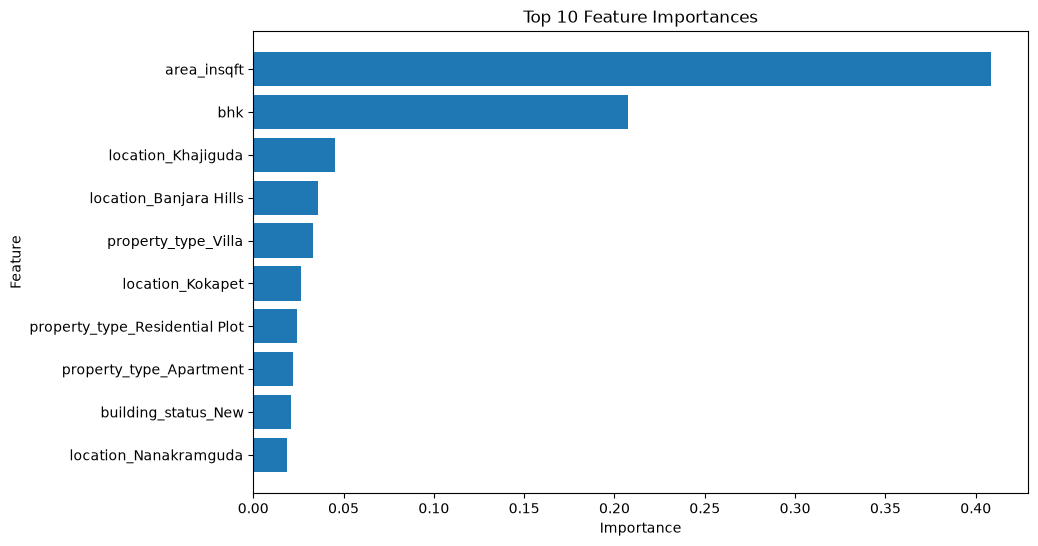

In [122]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['feature'], top10['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()



In [123]:
important_df.groupby('feature')['importance'].sum()

feature
area_insqft                        0.408626
bhk                                0.207461
building_status_New                0.020888
building_status_Ready to move      0.016803
building_status_Resale             0.005173
                                     ...   
property_type_Apartment            0.021760
property_type_Independent Floor    0.000731
property_type_Independent House    0.014127
property_type_Residential Plot     0.024137
property_type_Villa                0.032986
Name: importance, Length: 133, dtype: float64

In [124]:
def get_group(feature):
    if feature=='area_insqft':
        return 'Area'
    elif feature == 'bhk':
        return 'BHK'
    elif feature.startswith('location_'):
        return 'Location'
    elif feature.startswith('property_type_'):
        return 'Property Type'
    elif feature.startswith('building_status_'):
        return 'Building Status'
important_df['group']=important_df['feature'].apply(get_group)

In [125]:
important_df.head()

,feature,importance,group
0,location_AS Rao Nagar,0.000032,Location
1,location_Abids,0.001005,Location
2,location_Adibatla,0.000214,Location
3,location_Ameenpur,0.003145,Location
4,location_Aminpur,0.000306,Location


In [126]:
group_importance=important_df.groupby('group')['importance'].sum()

In [127]:
group_importance

group
Area               0.408626
BHK                0.207461
Building Status    0.059017
Location           0.231056
Property Type      0.093841
Name: importance, dtype: float64

In [129]:
error_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_predict_clf,
    'error': y_test.values - y_predict_clf,
    'absolute_error': np.abs(y_test.values - y_predict_clf)
})

error_df['location'] = x_test['location'].values
error_df['area_insqft'] = x_test['area_insqft'].values
error_df['building_status'] = x_test['building_status'].values
error_df['bhk'] = x_test['bhk'].values
error_df['property_type'] = x_test['property_type'].values

error_df = error_df.sort_values(
    'absolute_error',
    ascending=False
)

error_df.head(10)

,actual,predicted,error,absolute_error,location,area_insqft,building_status,bhk,property_type
77,2000.0,804.891533,1195.108467,1195.108467,Kokapet,4396,Ready to move,4,Villa
598,1500.0,321.340000,1178.660000,1178.660000,others,3850,Ready to move,4,Villa
555,235.0,696.561389,-461.561389,461.561389,Yapral,3200,Ready to move,5,Villa
92,750.0,290.146389,459.853611,459.853611,others,3200,Ready to move,4,Villa
501,625.0,179.057170,445.942830,445.942830,others,3750,Resale,0,Residential Plot
642,500.0,941.928533,-441.928533,441.928533,Gachibowli,5000,Ready to move,4,Villa
363,500.0,894.890000,-394.890000,394.890000,Bowenpally,6000,Ready to move,5,Villa
515,796.0,402.025667,393.974333,393.974333,Balapur,22392,New,0,Residential Plot
204,804.0,474.566667,329.433333,329.433333,Tellapur,4756,Under Construction,4,Villa
525,341.0,32.802573,308.197427,308.197427,Mirkhanpet,2196,Resale,0,Residential Plot


In [130]:
error_df[
    ['location', 'area_insqft', 'building_status',
     'bhk', 'property_type', 'actual',
     'predicted', 'absolute_error']
].head(10)

,location,area_insqft,building_status,bhk,property_type,actual,predicted,absolute_error
77,Kokapet,4396,Ready to move,4,Villa,2000.0,804.891533,1195.108467
598,others,3850,Ready to move,4,Villa,1500.0,321.340000,1178.660000
555,Yapral,3200,Ready to move,5,Villa,235.0,696.561389,461.561389
92,others,3200,Ready to move,4,Villa,750.0,290.146389,459.853611
501,others,3750,Resale,0,Residential Plot,625.0,179.057170,445.942830
642,Gachibowli,5000,Ready to move,4,Villa,500.0,941.928533,441.928533
363,Bowenpally,6000,Ready to move,5,Villa,500.0,894.890000,394.890000
515,Balapur,22392,New,0,Residential Plot,796.0,402.025667,393.974333
204,Tellapur,4756,Under Construction,4,Villa,804.0,474.566667,329.433333
525,Mirkhanpet,2196,Resale,0,Residential Plot,341.0,32.802573,308.197427


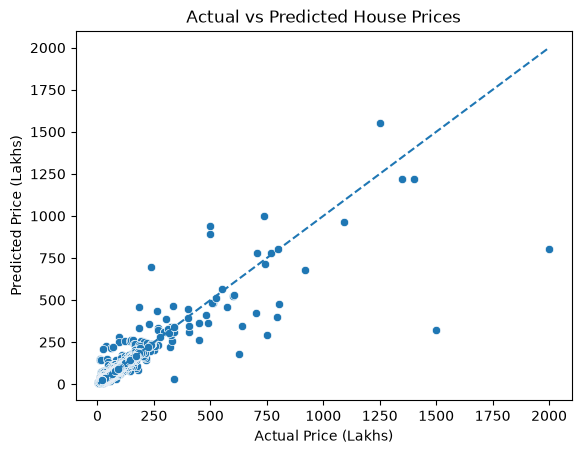

In [131]:
sns.scatterplot(

    x=error_df['actual'],
    y=error_df['predicted']
)
plt.plot(
    [error_df['actual'].min(), error_df['actual'].max()],
    [error_df['actual'].min(), error_df['actual'].max()],
    linestyle='--'
)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices')
plt.show()

**final Model Pipeline**


In [132]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor



In [133]:
categorical_cols = ['location', 'building_status', 'property_type']
numerical_cols = ['bhk', 'area_insqft']

In [134]:
processor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_cols)
    ],
    remainder='passthrough'

)

In [135]:
best_rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=None,
    random_state=43
)

In [136]:
final_pipeline=Pipeline([
    ('preprocessor',processor),
    ('model',best_rf)
])

In [137]:
final_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['location','area_insqft','building_status','bhk','property_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with 

In [138]:
y_pred_pipeline=final_pipeline.predict(x_test)

In [139]:
mse = mean_squared_error(y_test, y_pred_pipeline)
r2 = r2_score(y_test, y_pred_pipeline)
mae = mean_absolute_error(y_test, y_pred_pipeline)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 7222.538086440979
R2: 0.7637465808135866
MAE: 26.709312487192246
RMSE: 84.98551692165542


In [140]:
import pickle

with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)